In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Properly locate the repository root
def find_repo_root(start: Path = None) -> Path:
    if start is None:
        start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root with pyproject.toml and src/")

project_root = find_repo_root()
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

# Load HMF v3_iter3 data (with mass cut 1e11)
from galform_analysis.config import get_base_dir
from galform_analysis.analysis import (
    completed_galaxies,
    avg_correlation_given_redshift_and_subvolumes,
)
from galform_analysis.analysis.correlation.correlation import avg_correlation_given_redshift_and_subvolumes
import matplotlib as mpl
from galform_analysis.utils.matplotlib_config import setconfig

setconfig()

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

base_dir = Path(get_base_dir())
workspace_root = project_root

In [3]:
# Shared data path for DESI pair-count files used in the cells below
DATA_PATH = '/cosma/apps/durham/dc-hick2/galform_analysis/data/desi/'

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.ioff()

# DESI pair-count files available in this notebook workspace:
# z bins: 0.8_1.1, 1.1_1.6, and 0.8_1.6
path_data = DATA_PATH
redshift_bins = ['0.8_1.1', '1.1_1.6', '0.8_1.6']
tracer = 'ELG'
catalog = 'ELG_NScomb'
weights = 'default_bitwise_angular_FKP'


def load_counts(stat, zlim):
    name = f'allcounts_{catalog}_{zlim}_{weights}_log_njack128_nran18_split20.npy'
    fn = os.path.join(path_data, stat, name)
    return np.load(fn, allow_pickle=True).item()


def normalized_wcounts(counts):
    return counts['wcounts'] / counts['wnorm']


def landy_szalay(counts):
    dd = normalized_wcounts(counts['D1D2'])
    dr = normalized_wcounts(counts['D1R2'])
    rd = normalized_wcounts(counts['R1D2'])
    rr = normalized_wcounts(counts['R1R2'])
    xi = np.full_like(rr, np.nan, dtype='f8')
    np.divide(dd - dr - rd + rr, rr, out=xi, where=rr != 0)
    return xi

fig, axes = plt.subplots(len(redshift_bins), 2, figsize=(11, 3.4 * len(redshift_bins)))

for row, zlim in enumerate(redshift_bins):
    rppi = load_counts('rppi', zlim)
    smu = load_counts('smu', zlim)

    xi_rppi = landy_szalay(rppi)
    xi_smu = landy_szalay(smu)

    rp_edges = rppi['D1D2']['edges'][0]
    pi_edges = rppi['D1D2']['edges'][1]
    s_edges = smu['D1D2']['edges'][0]
    mu_edges = smu['D1D2']['edges'][1]

    ax_rppi = axes[row, 0]
    ax_smu = axes[row, 1]

    mesh0 = ax_rppi.pcolormesh(rp_edges, pi_edges, xi_rppi.T, shading='auto', cmap='coolwarm', vmin=-1.0, vmax=2.0)
    ax_rppi.set_xscale('log')
    ax_rppi.set_xlabel(r'$r_p$ [$\mathrm{Mpc}/h$]')
    ax_rppi.set_ylabel(r'$\pi$ [$\mathrm{Mpc}/h$]')
    ax_rppi.set_title(f'DESI ELG 2pcf, $z$ = {zlim} (rppi)')

    mesh1 = ax_smu.pcolormesh(s_edges, mu_edges, xi_smu.T, shading='auto', cmap='coolwarm', vmin=-1.0, vmax=2.0)
    ax_smu.set_xscale('log')
    ax_smu.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
    ax_smu.set_ylabel(r'$\mu$')
    ax_smu.set_title(f'DESI ELG 2pcf, $z$ = {zlim} (smu)')

fig.colorbar(mesh1, ax=axes.ravel().tolist(), shrink=0.9, label=r'$\xi$')
fig.subplots_adjust(hspace=0.35, wspace=0.2)
plt.close(fig)
print('Computed DESI 2pcf for z bins: ' + ', '.join(redshift_bins))

Computed DESI 2pcf for z bins: 0.8_1.1, 1.1_1.6, 0.8_1.6


In [5]:
# Show the computed DESI 2pcf values (summary per redshift bin)
import os
import numpy as np

path_data = DATA_PATH
redshift_bins = ['0.8_1.1', '1.1_1.6', '0.8_1.6']
catalog = 'ELG_NScomb'
weights = 'default_bitwise_angular_FKP'


def load_counts(stat, zlim):
    name = f'allcounts_{catalog}_{zlim}_{weights}_log_njack128_nran18_split20.npy'
    fn = os.path.join(path_data, stat, name)
    return np.load(fn, allow_pickle=True).item()


def norm_w(count):
    return count['wcounts'] / count['wnorm']


def xi_ls(counts):
    dd = norm_w(counts['D1D2'])
    dr = norm_w(counts['D1R2'])
    rd = norm_w(counts['R1D2'])
    rr = norm_w(counts['R1R2'])
    xi = np.full_like(rr, np.nan, dtype='f8')
    np.divide(dd - dr - rd + rr, rr, out=xi, where=rr != 0)
    return xi

for zlim in redshift_bins:
    rppi = load_counts('rppi', zlim)
    smu = load_counts('smu', zlim)

    xi_rppi = xi_ls(rppi)
    xi_smu = xi_ls(smu)

    rp_mid = 0.5 * (rppi['D1D2']['edges'][0][1:] + rppi['D1D2']['edges'][0][:-1])
    pi_mid = 0.5 * (rppi['D1D2']['edges'][1][1:] + rppi['D1D2']['edges'][1][:-1])
    s_mid = 0.5 * (smu['D1D2']['edges'][0][1:] + smu['D1D2']['edges'][0][:-1])
    mu_mid = 0.5 * (smu['D1D2']['edges'][1][1:] + smu['D1D2']['edges'][1][:-1])

    ipi0 = np.argmin(np.abs(pi_mid))
    imu0 = np.argmin(np.abs(mu_mid))

    print(f'\nDESI ELG z = {zlim}')
    print(f'  rppi slice at pi ~ {pi_mid[ipi0]:.1f}:')
    print('    rp [Mpc/h]    xi')
    for rp, val in zip(rp_mid[:15], xi_rppi[:15, ipi0]):
        print(f'    {rp:10.5f}  {val: .6e}')

    print(f'  smu slice at mu ~ {mu_mid[imu0]:.2f}:')
    print('    s  [Mpc/h]    xi')
    for s, val in zip(s_mid[:15], xi_smu[:15, imu0]):
        print(f'    {s:10.5f}  {val: .6e}')


DESI ELG z = 0.8_1.1
  rppi slice at pi ~ -0.5:
    rp [Mpc/h]    xi
       0.01106  -6.480055e+00
       0.01340   1.000000e+00
       0.01623   6.648499e+01
       0.01966   3.506278e+02
       0.02382   4.021147e+02
       0.02886   6.294822e+02
       0.03497   3.822220e+02
       0.04236   1.935886e+02
       0.05133   2.136426e+02
       0.06218   1.749678e+02
       0.07533   1.217675e+02
       0.09127   8.130564e+01
       0.11058   4.888017e+01
       0.13397   2.616960e+01
       0.16230   2.311635e+01
  smu slice at mu ~ -0.01:
    s  [Mpc/h]    xi
       0.01106   nan
       0.01340   nan
       0.01623   nan
       0.01966   nan
       0.02382   nan
       0.02886   nan
       0.03497   1.000000e+00
       0.04236   nan
       0.05133   nan
       0.06218   1.023861e+02
       0.07533   1.000000e+00
       0.09127   2.001199e+02
       0.11058   1.000000e+00
       0.13397   1.000000e+00
       0.16230  -1.382301e+00

DESI ELG z = 1.1_1.6
  rppi slice at pi ~ -0.5:
    r

/tmp/ipykernel_1036492/2205891968.py:51: RuntimeWarning: Mean of empty slice
  xi_r = np.nanmean(xi_smu, axis=1)


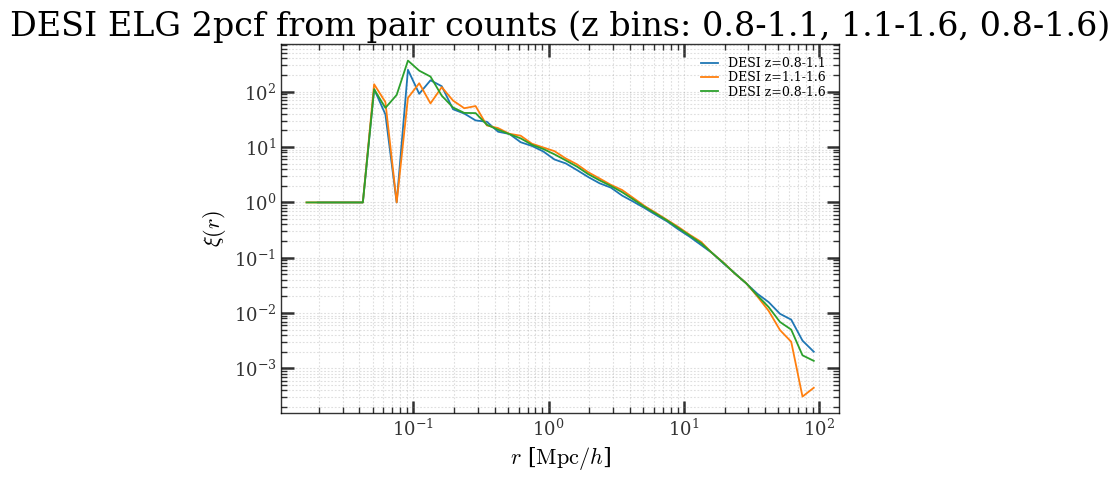

In [6]:
# Plot isotropic DESI 2pcf xi(r) on a log-r axis
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from galform_analysis.utils.matplotlib_config import setconfig

# Reset plotting state and apply project style config consistently
plt.close('all')
mpl.rcdefaults()
setconfig()
mpl.rcParams['lines.marker'] = 'None'

path_data = DATA_PATH
redshift_bins = ['0.8_1.1', '1.1_1.6', '0.8_1.6']
catalog = 'ELG_NScomb'
weights = 'default_bitwise_angular_FKP'


def load_counts(stat, zlim):
    name = f'allcounts_{catalog}_{zlim}_{weights}_log_njack128_nran18_split20.npy'
    fn = os.path.join(path_data, stat, name)
    return np.load(fn, allow_pickle=True).item()


def norm_w(count):
    return count['wcounts'] / count['wnorm']


def xi_landy_szalay(counts):
    dd = norm_w(counts['D1D2'])
    dr = norm_w(counts['D1R2'])
    rd = norm_w(counts['R1D2'])
    rr = norm_w(counts['R1R2'])
    xi = np.full_like(rr, np.nan, dtype='f8')
    np.divide(dd - dr - rd + rr, rr, out=xi, where=rr != 0)
    return xi


fig, ax = plt.subplots(figsize=(7.2, 4.8))

for zlim in redshift_bins:
    # Use smu counts and average over mu to obtain isotropic xi(r)~xi(s)
    smu = load_counts('smu', zlim)
    xi_smu = xi_landy_szalay(smu)

    s_edges = smu['D1D2']['edges'][0]
    s_mid = 0.5 * (s_edges[1:] + s_edges[:-1])

    with np.errstate(invalid='ignore'):
        xi_r = np.nanmean(xi_smu, axis=1)

    mask = np.isfinite(xi_r) & (s_mid > 0)
    ax.plot(s_mid[mask], xi_r[mask], lw=1.3, label=f'DESI z={zlim.replace("_", "-")}')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$r$ [$\mathrm{Mpc}/h$]')
ax.set_ylabel(r'$\xi(r)$')
z_label = ', '.join(z.replace('_', '-') for z in redshift_bins)
ax.set_title(f'DESI ELG 2pcf from pair counts (z bins: {z_label})')
ax.axhline(0.0, color='0.5', lw=0.8, ls='--')
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=9)

plt.show()

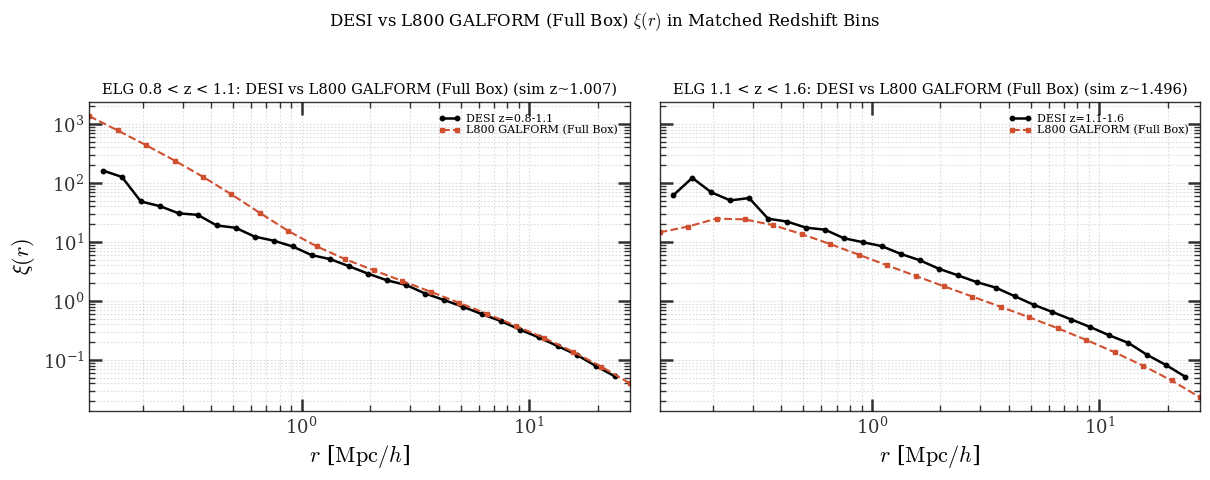

In [7]:
# Weighted correction vs DESI isotropic 2pcf at matched redshift bins
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from galform_analysis.utils.matplotlib_config import setconfig

plt.close('all')
mpl.rcdefaults()
setconfig()

def resolve_repo_root(start: Path) -> Path:
    if (start / 'data').exists() and (start / 'src').exists():
        return start
    for parent in start.parents:
        if (parent / 'data').exists() and (parent / 'src').exists():
            return parent
    raise FileNotFoundError('Could not locate repository root containing data/ and src/.')

project_root = resolve_repo_root(Path.cwd())
desi_data = project_root / 'data' / 'desi'
catalog = 'ELG_NScomb'
weights = 'default_bitwise_angular_FKP'

# Choose weighted-correction CSVs that exist in this workspace (n_subvol=1024).
weighted_sources = {
    '0.8_1.1': project_root / 'data' / 'convergence' / 'group_sampling_jobs_by_nvol' / 'n1024' / 'weighted' / 'L800' / 'group_sampling_convergence_weighted_L800_iz176.csv',
    '1.1_1.6': project_root / 'data' / 'halo_sampling_6_subvol_weighted_mstar_scan' / 'lc16' / 'iz155' / 'ntotal_1024' / 'custom' / 'mhalo_1e11' / 'centrals_1' / 'mstar_none' / 'nsubvol_1024' / 'halo_sampling_convergence_weighted_L800_iz155.csv',
}

sim_z_lookup = {}
for iz in ['176', '155']:
    z_path = project_root / 'data' / 'convergence' / 'legacy' / 'convergence_results_mhalo1e10' / f'corr_convergence_iz{iz}.csv'
    if z_path.exists():
        z_df = pd.read_csv(z_path)
        if 'z' in z_df.columns and len(z_df):
            sim_z_lookup[iz] = float(z_df['z'].iloc[0])


def load_counts(stat, zlim):
    name = f'allcounts_{catalog}_{zlim}_{weights}_log_njack128_nran18_split20.npy'
    return np.load(desi_data / stat / name, allow_pickle=True).item()


def norm_w(count):
    return count['wcounts'] / count['wnorm']


def xi_landy_szalay(counts):
    dd = norm_w(counts['D1D2'])
    dr = norm_w(counts['D1R2'])
    rd = norm_w(counts['R1D2'])
    rr = norm_w(counts['R1R2'])
    xi = np.full_like(rr, np.nan, dtype='f8')
    np.divide(dd - dr - rd + rr, rr, out=xi, where=rr != 0)
    return xi


fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharey=True)

for ax, zbin in zip(axes, ['0.8_1.1', '1.1_1.6']):
    # DESI isotropic xi(s): Landy-Szalay in (s, mu), averaged over mu.
    smu = load_counts('smu', zbin)
    xi_smu = xi_landy_szalay(smu)
    s_edges = smu['D1D2']['edges'][0]
    s_mid = 0.5 * (s_edges[1:] + s_edges[:-1])
    valid_counts = np.isfinite(xi_smu).sum(axis=1)
    xi_desi = np.divide(
        np.nansum(xi_smu, axis=1),
        valid_counts,
        out=np.full(s_mid.shape, np.nan, dtype='f8'),
        where=valid_counts > 0,
    )

    desi_mask = np.isfinite(xi_desi) & (xi_desi > 0) & (s_mid > 0)
    desi_r = s_mid[desi_mask]
    desi_xi = xi_desi[desi_mask]

    # Weighted-correction simulation xi(r).
    wpath = weighted_sources[zbin]
    if not wpath.exists():
        raise FileNotFoundError(f'Weighted CSV not found: {wpath}')
    wdf = pd.read_csv(wpath).sort_values('r')
    xi_col = 'xi_corrected' if 'xi_corrected' in wdf.columns else 'xi'
    sim_mask = np.isfinite(wdf[xi_col]) & (wdf[xi_col] > 0) & (wdf['r'] > 0)
    sim_r = wdf.loc[sim_mask, 'r'].to_numpy()
    sim_xi = wdf.loc[sim_mask, xi_col].to_numpy()

    # The z=1.1-1.6 simulation CSV is stored as (1 + xi), so shift to xi.
    shifted_minus_one = zbin == '1.1_1.6'
    if shifted_minus_one:
        sim_xi = sim_xi - 1.0
        positive = sim_xi > 0
        sim_r = sim_r[positive]
        sim_xi = sim_xi[positive]

    # Restrict plotting range to the r-overlap where both datasets exist.
    r_min = max(desi_r.min(), sim_r.min())
    r_max = min(desi_r.max(), sim_r.max())
    if not np.isfinite(r_min) or not np.isfinite(r_max) or (r_min >= r_max):
        raise ValueError(f'No overlapping r-range for z bin {zbin}.')

    desi_common = (desi_r >= r_min) & (desi_r <= r_max)
    sim_common = (sim_r >= r_min) & (sim_r <= r_max)

    ax.loglog(
        desi_r[desi_common],
        desi_xi[desi_common],
        lw=1.8,
        marker='o',
        markersize=3.2,
        color='black',
        label=f'DESI z={zbin.replace("_", "-")}',
    )
    ax.loglog(
        sim_r[sim_common],
        sim_xi[sim_common],
        lw=1.5,
        ls='--',
        marker='s',
        markersize=3.0,
        color='#d04f2f',
        label='L800 GALFORM (Full Box)',
    )

    sim_z = None
    if 'iz176' in wpath.name:
        sim_z = sim_z_lookup.get('176')
    elif 'iz155' in wpath.name:
        sim_z = sim_z_lookup.get('155')

    z_text = zbin.replace('_', ' < z < ')
    sim_text = f'sim z~{sim_z:.3f}' if sim_z is not None else 'sim z unavailable'
    ax.set_title(f'ELG {z_text}: DESI vs L800 GALFORM (Full Box) ({sim_text})', fontsize=10.5)
    ax.set_xlabel(r'$r$ [$\mathrm{Mpc}/h$]')
    ax.set_xlim(r_min, r_max)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r'$\xi(r)$')
fig.suptitle(r'DESI vs L800 GALFORM (Full Box) $\xi(r)$ in Matched Redshift Bins', fontsize=12)
fig.tight_layout()
plt.show()

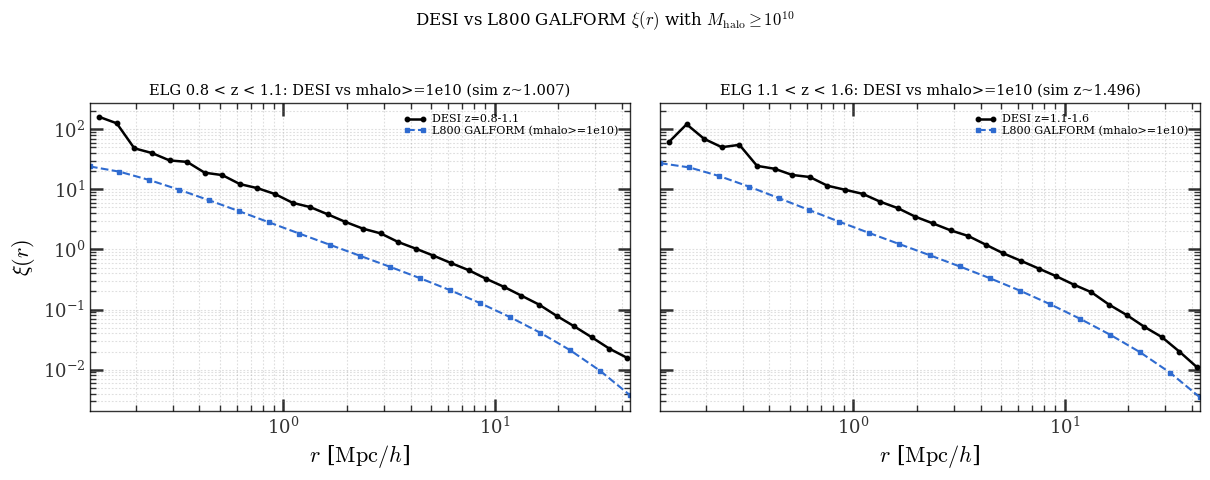

In [8]:
# DESI vs L800 GALFORM with alternative mass cut: mhalo >= 1e10
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from galform_analysis.utils.matplotlib_config import setconfig

plt.close('all')
mpl.rcdefaults()
setconfig()

def resolve_repo_root(start: Path) -> Path:
    if (start / 'data').exists() and (start / 'src').exists():
        return start
    for parent in start.parents:
        if (parent / 'data').exists() and (parent / 'src').exists():
            return parent
    raise FileNotFoundError('Could not locate repository root containing data/ and src/.')

project_root = resolve_repo_root(Path.cwd())
desi_data = project_root / 'data' / 'desi'
catalog = 'ELG_NScomb'
weights = 'default_bitwise_angular_FKP'

# Alternative simulation CSVs at mhalo_1e10.
sim_sources = {
    '0.8_1.1': project_root / 'data' / 'convergence' / 'legacy' / 'convergence_results_mhalo1e10' / 'corr_convergence_iz176.csv',
    '1.1_1.6': project_root / 'data' / 'convergence' / 'legacy' / 'convergence_results_mhalo1e10' / 'corr_convergence_iz155.csv',
}

n_ivol_target = 1024

def load_counts(stat, zlim):
    name = f'allcounts_{catalog}_{zlim}_{weights}_log_njack128_nran18_split20.npy'
    return np.load(desi_data / stat / name, allow_pickle=True).item()


def norm_w(count):
    return count['wcounts'] / count['wnorm']


def xi_landy_szalay(counts):
    dd = norm_w(counts['D1D2'])
    dr = norm_w(counts['D1R2'])
    rd = norm_w(counts['R1D2'])
    rr = norm_w(counts['R1R2'])
    xi = np.full_like(rr, np.nan, dtype='f8')
    np.divide(dd - dr - rd + rr, rr, out=xi, where=rr != 0)
    return xi


fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharey=True)

for ax, zbin in zip(axes, ['0.8_1.1', '1.1_1.6']):
    # DESI isotropic xi(s): Landy-Szalay in (s, mu), averaged over mu.
    smu = load_counts('smu', zbin)
    xi_smu = xi_landy_szalay(smu)
    s_edges = smu['D1D2']['edges'][0]
    s_mid = 0.5 * (s_edges[1:] + s_edges[:-1])
    valid_counts = np.isfinite(xi_smu).sum(axis=1)
    xi_desi = np.divide(
        np.nansum(xi_smu, axis=1),
        valid_counts,
        out=np.full(s_mid.shape, np.nan, dtype='f8'),
        where=valid_counts > 0,
    )

    desi_mask = np.isfinite(xi_desi) & (xi_desi > 0) & (s_mid > 0)
    desi_r = s_mid[desi_mask]
    desi_xi = xi_desi[desi_mask]

    # Alternative simulation xi(r) from mhalo_1e10 CSVs.
    spath = sim_sources[zbin]
    if not spath.exists():
        raise FileNotFoundError(f'Simulation CSV not found: {spath}')
    sdf = pd.read_csv(spath).sort_values('r')
    if 'n_ivols' in sdf.columns:
        sdf = sdf[sdf['n_ivols'] == n_ivol_target].copy()
    if len(sdf) == 0:
        raise ValueError(f'No rows for n_ivols={n_ivol_target} in {spath.name}')

    sim_mask = np.isfinite(sdf['xi']) & (sdf['xi'] > 0) & (sdf['r'] > 0)
    sim_r = sdf.loc[sim_mask, 'r'].to_numpy()
    sim_xi = sdf.loc[sim_mask, 'xi'].to_numpy()

    # Restrict plotting range to the r-overlap where both datasets exist.
    r_min = max(desi_r.min(), sim_r.min())
    r_max = min(desi_r.max(), sim_r.max())
    if not np.isfinite(r_min) or not np.isfinite(r_max) or (r_min >= r_max):
        raise ValueError(f'No overlapping r-range for z bin {zbin}.')

    desi_common = (desi_r >= r_min) & (desi_r <= r_max)
    sim_common = (sim_r >= r_min) & (sim_r <= r_max)

    ax.loglog(
        desi_r[desi_common],
        desi_xi[desi_common],
        lw=1.8,
        marker='o',
        markersize=3.2,
        color='black',
        label=f'DESI z={zbin.replace("_", "-")}',
    )
    ax.loglog(
        sim_r[sim_common],
        sim_xi[sim_common],
        lw=1.5,
        ls='--',
        marker='s',
        markersize=3.0,
        color='#2f6bd0',
        label='L800 GALFORM (mhalo>=1e10)',
    )

    sim_z = float(sdf['z'].iloc[0]) if 'z' in sdf.columns else np.nan
    z_text = zbin.replace('_', ' < z < ')
    sim_text = f'sim z~{sim_z:.3f}' if np.isfinite(sim_z) else 'sim z unavailable'
    ax.set_title(f'ELG {z_text}: DESI vs mhalo>=1e10 ({sim_text})', fontsize=10.5)
    ax.set_xlabel(r'$r$ [$\mathrm{Mpc}/h$]')
    ax.set_xlim(r_min, r_max)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r'$\xi(r)$')
fig.suptitle(r'DESI vs L800 GALFORM $\xi(r)$ with $M_{\mathrm{halo}} \geq 10^{10}$', fontsize=12)
fig.tight_layout()
plt.show()

In [9]:
# Inspect aggregated DESI FITS; if no precomputed xi, plot n(z), sky positions,
# and fall back to plotting isotropic xi(r) from the pair-count `.npy` files.
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# New DESI DR1 data location on cosma5 with aggregated catalogs + random splits
desi_path_large = Path('/cosma5/data/durham/dc-hick2/DESI/dr1_guadalupe_v1.0')

files = [
    desi_path_large / 'ELG_LOPnotqso_N_clustering.dat.fits',
    desi_path_large / 'ELG_LOPnotqso_S_clustering.dat.fits',
]

found_xi = False
for fn in files:
    if not fn.exists():
        print(f'File not found: {fn}')
        continue
    with fits.open(fn) as hdul:
        print('\nOpened', fn.name)
        hdul.info()
        # find first table HDU
        table_hdu = None
        for h in hdul:
            if isinstance(h, fits.BinTableHDU) or isinstance(h, fits.TableHDU):
                table_hdu = h
                break
        if table_hdu is None:
            print(f'No table HDU found in {fn.name}')
            continue
        data = table_hdu.data
        cols = data.names
        print('columns:', cols)

        # check for precomputed xi
        xi_col = next((c for c in cols if 'xi' in c.lower()), None)
        r_col = next((c for c in cols if c.lower() in ('r','ravg','rad','radial','ravg_bin','radius')), None)
        if xi_col is not None and r_col is not None:
            r = np.array(data[r_col])
            xi = np.array(data[xi_col])
            plt.figure(figsize=(6,4))
            plt.plot(r, xi, marker='o', linestyle='-', label=fn.name)
            plt.xscale('log')
            plt.xlabel('r [Mpc/h]')
            plt.ylabel(r'$\xi(r)$')
            plt.title('DESI DR1 ELG 2PCF (from FITS)')
            plt.legend()
            plt.grid(True, which='both', ls=':', alpha=0.6)
            plt.show()
            found_xi = True
        else:
            # no xi in catalog: show n(z) and sky positions as quick diagnostics
            print('No precomputed xi in catalog; plotting n(z) and sky positions as diagnostics.')
            if all(k in cols for k in ('Z','RA','DEC')):
                z = np.array(data['Z'])
                ra = np.array(data['RA'])
                dec = np.array(data['DEC'])

                fig, axes = plt.subplots(1,2,figsize=(10,4))
                axes[0].hist(z[np.isfinite(z)], bins=40, color='C0')
                axes[0].set_xlabel('z')
                axes[0].set_title(fn.name + ' n(z)')

                # downsample sky points for plotting
                sel = np.random.default_rng(0).choice(len(ra), size=min(2000, len(ra)), replace=False)
                axes[1].scatter(ra[sel], dec[sel], s=1, alpha=0.6)
                axes[1].set_xlabel('RA [deg]')
                axes[1].set_ylabel('DEC [deg]')
                axes[1].set_title(fn.name + ' sky positions (downsampled)')
                plt.tight_layout()
                plt.show()
            else:
                print('Catalog does not include (Z, RA, DEC) to plot n(z) / sky positions.')

# If no precomputed xi, fallback to plotting isotropic xi(r) from pair-count `.npy` files
if not found_xi:
    print('\nFalling back to plotting isotropic xi(r) from existing pair-count files (smu).')
    # Minimal local implementation of the pair-count loader + Landy-Szalay used elsewhere in this notebook
    import os
    DATA_PATH = '/cosma/apps/durham/dc-hick2/galform_analysis/data/desi/'
    redshift_bins = ['0.8_1.1', '1.1_1.6', '0.8_1.6']
    catalog = 'ELG_NScomb'
    weights = 'default_bitwise_angular_FKP'

    def load_counts(stat, zlim):
        name = f'allcounts_{catalog}_{zlim}_{weights}_log_njack128_nran18_split20.npy'
        fn = os.path.join(DATA_PATH, stat, name)
        return np.load(fn, allow_pickle=True).item()

    def norm_w(count):
        return count['wcounts'] / count['wnorm']

    def xi_landy_szalay(counts):
        dd = norm_w(counts['D1D2'])
        dr = norm_w(counts['D1R2'])
        rd = norm_w(counts['R1D2'])
        rr = norm_w(counts['R1R2'])
        xi = np.full_like(rr, np.nan, dtype='f8')
        np.divide(dd - dr - rd + rr, rr, out=xi, where=rr != 0)
        return xi

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    for zlim in redshift_bins:
        try:
            smu = load_counts('smu', zlim)
        except FileNotFoundError:
            print(f'Pair-count file missing for z bin {zlim}; skipping.')
            continue
        xi_smu = xi_landy_szalay(smu)
        s_edges = smu['D1D2']['edges'][0]
        s_mid = 0.5 * (s_edges[1:] + s_edges[:-1])
        with np.errstate(invalid='ignore'):
            xi_r = np.nanmean(xi_smu, axis=1)
        mask = np.isfinite(xi_r) & (s_mid > 0)
        ax.plot(s_mid[mask], xi_r[mask], lw=1.3, label=f'DESI z={zlim.replace("_","-")}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$r$ [$\mathrm{Mpc}/h$]')
    ax.set_ylabel(r'$\xi(r)$')
    z_label = ', '.join(z.replace('_', '-') for z in redshift_bins)
    ax.set_title(f'DESI ELG 2pcf from pair counts (z bins: {z_label})')
    ax.axhline(0.0, color='0.5', lw=0.8, ls='--')
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=9)
    plt.show()
else:
    print('\nPlotted xi(r) from FITS catalog(s).')

/cosma/apps/durham/dc-hick2/galform_analysis/data/desi/dr1_guadalupe_v1.0/ELG_LOPnotqso_N_clustering.dat.fits
Filename: /cosma/apps/durham/dc-hick2/galform_analysis/data/desi/dr1_guadalupe_v1.0/ELG_LOPnotqso_N_clustering.dat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  LSS           1 BinTableHDU     34   55383R x 12C   [K, D, K, 9A, D, D, D, D, D, D, D, D]   
columns: ['TARGETID', 'Z', 'NTILE', 'TILES', 'RA', 'DEC', 'WEIGHT', 'WEIGHT_ZFAIL', 'WEIGHT_COMP', 'WEIGHT_SYS', 'NZ', 'WEIGHT_FKP']
No (r, xi) columns found. Preview first 5 rows:
[(39633359621588874, 0.81109494, 1, '1001', 267.8835759 , 57.65399789, 2.19153213, 1.02486763, 2., 1.06917813, 0.0008158 , 0.53349477)
 (39633359621588473, 1.06936969, 1, '1001', 267.8395001 , 57.75281398, 6.44591488, 1.        , 6., 1.07431915, 0.00068075, 0.57814104)
 (39633359621588055, 1.12665404, 1, '1001', 267.78907323, 57.71757993, 3.29300004, 1.02664527, 3., 1.0691781